In [718]:
from pathlib import Path
import os

# Detectamos la ruta donde está guardado este notebook
notebook_dir = Path().resolve()
print(f"Directorio actual del notebook:\n{notebook_dir}\n")

# Cambiamos el directorio de trabajo a esta misma ruta
os.chdir(notebook_dir)

# Confirmamos
print(f"Nuevo directorio de trabajo:\n{os.getcwd()}")


Directorio actual del notebook:
C:\Users\admin\Documents\Códigos Pytohn\UNIDAD 4

Nuevo directorio de trabajo:
C:\Users\admin\Documents\Códigos Pytohn\UNIDAD 4


In [719]:
# === Librerías ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests, zipfile, io
import statsmodels.api as sm
# from ISLP import load_data   # Comentado: no está instalado y no se usa en el TP4

from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score,
    roc_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Configuración general
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style="whitegrid", palette="deep")

In [720]:
# === Cargar base del TP2 ===

#Traemos solo 2025 que lo limpiamos en el python anterior directamente
eph = pd.read_csv("eph_tp3.csv")


#La base cargada tiene algunas transformaciones adicionales. Se agregaron variables asociadas a características del jefe de hogar:
#jefe_ocupado, una dummy que toma 1 cuando el jefe de hogar de ese hogar está ocupado y se repite para todos sus miembros
#educ_jefe, una dummy que establece los años de educación del jefe de hogar para todos los miembros del hogar
#jefe_mujer,una dummy que establece si el/la jefe es mujer.
#ninos_hogar, cantidad de niños en el hogar


print("Base cargada correctamente.")
print("Filas y columnas:", eph.shape)
display(eph.head(10))


Base cargada correctamente.
Filas y columnas: (4057, 11)


,ch06,Sexo_Varón,educ,estado_Ocupado,cobertura_medica_tiene,pobre,estado_civil_no_casado,jefe_ocupado,educ_jefe,jefe_mujer,ninos_hogar
0,48,0,19.00,1,1,1,1,1,19.00,1,1
1,17,1,13.00,0,1,1,1,1,19.00,1,1
2,9,1,4.00,0,1,1,1,1,19.00,1,1
3,39,1,11.00,1,0,0,1,1,11.00,0,0
4,36,0,13.00,1,1,0,1,1,13.00,1,0
5,30,1,13.00,1,1,0,1,1,13.00,0,0
6,54,0,13.00,1,1,0,1,1,13.00,1,0
7,29,0,15.00,1,1,0,1,1,15.00,1,0
8,4,1,0.00,0,0,1,1,0,10.00,1,4
9,41,0,13.00,1,1,0,1,1,13.00,1,1


# A. Modelo de Regresión Logística con Regularización: Ridge y LASSO

## 1. Visualización de grilla de parámetros de penalidad - LASSO y Ridge

In [723]:
y = eph['pobre']

In [724]:
#Seleccionamos las variables numéricas para estandarizarlas, largando las dummies y la dependiente

# Columnas numéricas
cols_num = ['ch06', 'educ', 'educ_jefe',"ninos_hogar"]

# Columnas dummy
cols_dummy = ['Sexo_Varón',
              'estado_Ocupado',
              'cobertura_medica_tiene',
              'estado_civil_no_casado',
              'jefe_ocupado',
              'jefe_mujer']

X_num = eph[cols_num]
X_dummy = eph[cols_dummy]

X_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4057 entries, 0 to 4056
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ch06         4057 non-null   int64  
 1   educ         4057 non-null   float64
 2   educ_jefe    4057 non-null   float64
 3   ninos_hogar  4057 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 126.9 KB


In [725]:
X_num = X_num.reset_index(drop=True) # index original es descartado
X_num

,ch06,educ,educ_jefe,ninos_hogar
0,48,19.00,19.00,1
1,17,13.00,19.00,1
2,9,4.00,19.00,1
3,39,11.00,11.00,0
4,36,13.00,13.00,0
...,...,...,...,...
4052,55,13.00,13.00,0
4053,49,7.00,13.00,0
4054,35,7.00,13.00,0
4055,26,12.00,13.00,0


In [726]:
# Iniciamos el Standard Scaler
sc = StandardScaler()

# Estandarizamos las observaciones de entrenamiento
X_transformed = pd.DataFrame(sc.fit_transform(X_num),index=X_num.index, columns=X_num.columns)

X_transformed

,ch06,educ,educ_jefe,ninos_hogar
0,0.45,1.67,1.69,0.24
1,-0.95,0.44,1.69,0.24
2,-1.31,-1.40,1.69,0.24
3,0.05,0.03,-0.29,-0.77
4,-0.09,0.44,0.21,-0.77
...,...,...,...,...
4052,0.77,0.44,0.21,-0.77
4053,0.50,-0.79,0.21,-0.77
4054,-0.13,-0.79,0.21,-0.77
4055,-0.54,0.24,0.21,-0.77


In [727]:
X = pd.concat([X_transformed, X_dummy.astype(float)], axis=1)

X

,ch06,educ,educ_jefe,ninos_hogar,Sexo_Varón,estado_Ocupado,cobertura_medica_tiene,estado_civil_no_casado,jefe_ocupado,jefe_mujer
0,0.45,1.67,1.69,0.24,0.00,1.00,1.00,1.00,1.00,1.00
1,-0.95,0.44,1.69,0.24,1.00,0.00,1.00,1.00,1.00,1.00
2,-1.31,-1.40,1.69,0.24,1.00,0.00,1.00,1.00,1.00,1.00
3,0.05,0.03,-0.29,-0.77,1.00,1.00,0.00,1.00,1.00,0.00
4,-0.09,0.44,0.21,-0.77,0.00,1.00,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...
4052,0.77,0.44,0.21,-0.77,0.00,0.00,1.00,1.00,0.00,1.00
4053,0.50,-0.79,0.21,-0.77,1.00,1.00,1.00,1.00,0.00,1.00
4054,-0.13,-0.79,0.21,-0.77,1.00,0.00,1.00,1.00,0.00,1.00
4055,-0.54,0.24,0.21,-0.77,0.00,1.00,1.00,1.00,0.00,1.00


In [728]:
# Train test split
X_train_regularizacion, X_test_regularizacion, y_train_regularizacion, y_test_regularizacion = train_test_split(X, y, test_size=0.3, random_state=100)

# Revisamos cuantas observaciones quedaron para Test y cuantas para Entrenamiento.
print(f'El conjunto de entrenamiento tiene {len(X_train)} observaciones.')
print(f'El conjunto de test tiene {len(X_test)} observaciones.')

El conjunto de entrenamiento tiene 2839 observaciones.
El conjunto de test tiene 1218 observaciones.


In [729]:
# defino el espacio de lambdas
lambdas = np.logspace(-5, 5, 11)  

# Defino los C, que serán los lambdas de la regresión lineal
Cs = 1 / lambdas

In [730]:
coefs_ridge = []  
coefs_lasso = [] 

#Armo loops para recorrer los distintos valores de lambda

for C in Cs:
    #Ridge
    logit_ridge = LogisticRegression(penalty='l2',C=C,solver='lbfgs',max_iter=500)
    logit_ridge.fit(X_train_regularizacion, y_train_regularizacion)
    coefs_ridge.append(logit_ridge.coef_[0]) 

    # ----- LASSO (L1) -----
    logit_lasso = LogisticRegression(penalty='l1', C=C,solver='liblinear',max_iter=500)
    logit_lasso.fit(X_train_regularizacion, y_train_regularizacion)
    coefs_lasso.append(logit_lasso.coef_[0])

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

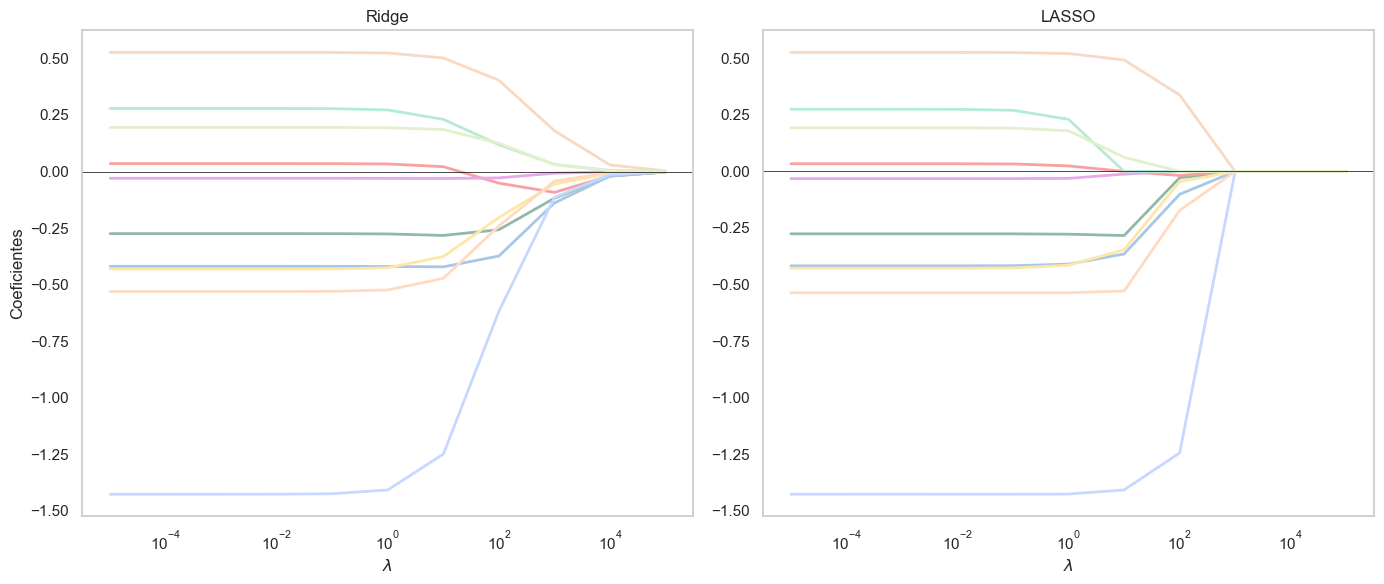

In [731]:
colores = [
    "#8FB9A8", "#F7A1A1", "#A7C7E7", "#F7D9C4", "#E6A9EC",
    "#FFE6A7", "#C6D8FF", "#B5EAD7", "#FFDAC1", "#E2F0CB"
]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Ridge 
for i, col in enumerate(X_train_regularizacion.columns):
    axs[0].plot(lambdas, coefs_ridge[:, i], 
                color=colores[i % len(colores)], linewidth=2)
    
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$\lambda$')
axs[0].set_ylabel('Coeficientes')
axs[0].set_title('Ridge')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].grid(False)

#LASSO
for i, col in enumerate(X_train_regularizacion.columns):
    axs[1].plot(lambdas, coefs_lasso[:, i], 
                color=colores[i % len(colores)], linewidth=2)

axs[1].set_xscale('log')
axs[1].set_xlabel(r'$\lambda$')
axs[1].set_title('LASSO')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].grid(False)

plt.tight_layout()
plt.show()

In [732]:
#Matriz de Ridge para ver como se va comprimiendo los coeficientes a medida que aumenta lambda

coefs_ridge = []

for C in Cs:
    model = LogisticRegression(penalty='l2',C=C,solver='lbfgs', max_iter=500)
    model.fit(X_train_regularizacion, y_train_regularizacion)
    coefs_ridge.append(model.coef_[0])

coefs_ridge = np.array(coefs_ridge)
coefs_ridge

array([[-2.74396341e-01,  3.48607814e-02, -4.18831063e-01,
         5.26346329e-01, -2.98174885e-02, -4.31337810e-01,
        -1.42601953e+00,  2.78627048e-01, -5.30236136e-01,
         1.94945251e-01],
       [-2.74396474e-01,  3.48606554e-02, -4.18831109e-01,
         5.26346066e-01, -2.98175174e-02, -4.31337226e-01,
        -1.42601771e+00,  2.78626349e-01, -5.30235535e-01,
         1.94945176e-01],
       [-2.74397800e-01,  3.48593948e-02, -4.18831573e-01,
         5.26343428e-01, -2.98178065e-02, -4.31331385e-01,
        -1.42599945e+00,  2.78619354e-01, -5.30229518e-01,
         1.94944418e-01],
       [-2.74411057e-01,  3.48467897e-02, -4.18836203e-01,
         5.26317061e-01, -2.98206993e-02, -4.31272995e-01,
        -1.42581695e+00,  2.78549428e-01, -5.30169362e-01,
         1.94936842e-01],
       [-2.74543034e-01,  3.47208295e-02, -4.18882140e-01,
         5.26053906e-01, -2.98497606e-02, -4.30690431e-01,
        -1.42399531e+00,  2.77852296e-01, -5.29568954e-01,
         1.

In [733]:
#Matriz de Lasso. En este caso se ve como se van haciendo cero

coefs_lasso = []

for C in Cs:
    model = LogisticRegression(penalty='l1',C=C,solver='liblinear',max_iter=500)
    model.fit(X_train_regularizacion, y_train_regularizacion)
    coefs_lasso.append(model.coef_[0])

coefs_lasso = np.array(coefs_lasso)
coefs_lasso

array([[-0.27580008,  0.03404509, -0.41764854,  0.5262771 , -0.03163835,
        -0.42802239, -1.42715006,  0.2750133 , -0.53625632,  0.19296797],
       [-0.27563779,  0.0340858 , -0.41777625,  0.52629544, -0.03125715,
        -0.42797654, -1.42668626,  0.27604016, -0.53572687,  0.19324305],
       [-0.27586767,  0.03404578, -0.41760348,  0.52625728, -0.03159021,
        -0.42799376, -1.42730243,  0.27477598, -0.53642515,  0.19292024],
       [-0.27585142,  0.03396095, -0.41754809,  0.52623964, -0.03156794,
        -0.42785283, -1.42727287,  0.2744837 , -0.53643063,  0.19275085],
       [-0.27572409,  0.03307598, -0.41697921,  0.52580777, -0.03123905,
        -0.42659035, -1.42657614,  0.27199511, -0.53576426,  0.19190087],
       [-0.27749009,  0.02438156, -0.41002852,  0.5212144 , -0.03078653,
        -0.41470234, -1.42664664,  0.23038128, -0.53630093,  0.18021684],
       [-0.28352123,  0.        , -0.36503914,  0.49309587, -0.01202824,
        -0.34621195, -1.40833322,  0.        

## 2.Penalidad óptima por Cross-validation y visualización

In [735]:
# Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=100)

resultados = []

for C in Cs:
    errores = []
    
    for train_index, val_index in kf.split(X_train_regularizacion):
        X_tr, X_val = X_train_regularizacion.iloc[train_index], X_train_regularizacion.iloc[val_index]
        y_tr, y_val = y_train_regularizacion.iloc[train_index], y_train_regularizacion.iloc[val_index]

        modelo = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=500)
        modelo.fit(X_tr, y_tr)
        prediccion = modelo.predict(X_val)
        
        acc = accuracy_score(y_val, prediccion)
        error = 1 - acc
        errores.append(error)
    
    resultados.append(np.mean(errores))

mejor_ridge = np.argmin(resultados)
mejor_lambda_ridge = lambdas[mejor_ridge]
mejor_error_ridge = resultados[mejor_ridge]

print("Mejor lambda en Ridge:", mejor_lambda_ridge)
print("Menor error de clasificación en Ridge:", round(mejor_error_ridge, 4))

Mejor lambda en Ridge: 1e-05
Menor error de clasificación en Ridge: 0.1814


In [736]:
# LASSO
kf = KFold(n_splits=5, shuffle=True, random_state=100)

resultados_lasso = []

for C in Cs:
    errores = []    
    for train_index, val_index in kf.split(X_train):
        X_tr, X_val = X_train_regularizacion.iloc[train_index], X_train_regularizacion.iloc[val_index]
        y_tr, y_val = y_train_regularizacion.iloc[train_index], y_train_regularizacion.iloc[val_index]

        modelo = LogisticRegression(penalty='l1',C=C,solver='liblinear',max_iter=500)
        modelo.fit(X_tr, y_tr)
        prediccion = modelo.predict(X_val)
        
        acc = accuracy_score(y_val, prediccion)
        error = 1 - acc
        errores.append(error)
    
    resultados_lasso.append(np.mean(errores))

mejor_lasso = np.argmin(resultados_lasso)
mejor_lambda_lasso = lambdas[mejor_lasso]
mejor_error_lasso = resultados_lasso[mejor_lasso]

print("Mejor lambda en LASSO:", mejor_lambda_lasso)
print("Menor error de clasificación en LASSO:", round(mejor_error_lasso, 4))

Mejor lambda en LASSO: 100.0
Menor error de clasificación en LASSO: 0.1814


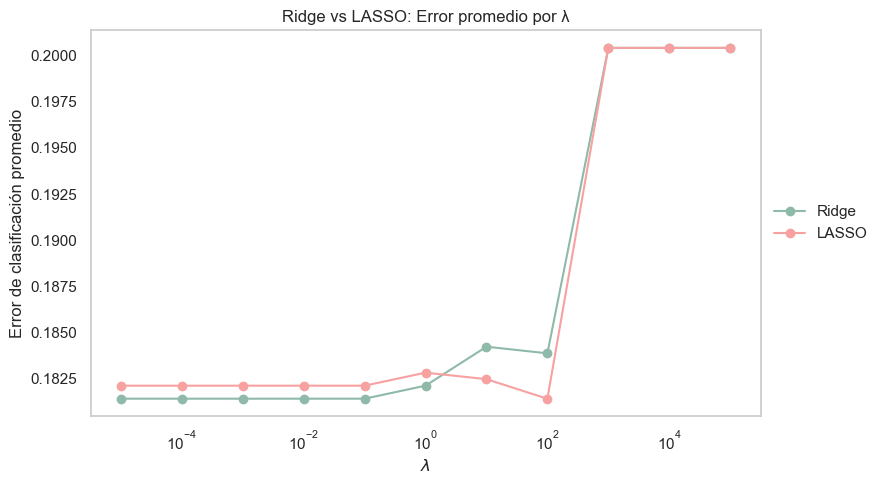

In [737]:
plt.figure(figsize=(9,5))
color_ridge = '#8FB9A8'   # verde pastel suave
color_lasso = '#F7A1A1'   # rojo pastel suave
plt.plot(lambdas, resultados, marker='o', linestyle='-', label='Ridge', color=color_ridge)
plt.plot(lambdas, resultados_lasso, marker='o', linestyle='-', label='LASSO', color=color_lasso)
plt.xscale('log')
plt.xlabel(r'$\lambda$')
plt.ylabel('Error de clasificación promedio')
plt.title('Ridge vs LASSO: Error promedio por λ')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()

## Estimación con lambda por cross-validation y comparación de coeficientes

In [739]:

logit = LogisticRegression(solver='lbfgs',max_iter=1000)
logit.fit(X_train, y_train)
coef_logit = logit.coef_[0]


lasso = LogisticRegression(penalty='l1',C=1/mejor_lambda_lasso,solver='liblinear', max_iter=1000)
lasso.fit(X_train, y_train)
coef_lasso = lasso.coef_[0]


ridge = LogisticRegression(penalty='l2', C=1/mejor_lambda_ridge,solver='lbfgs',max_iter=1000)
ridge.fit(X_train, y_train)
coef_ridge = ridge.coef_[0]

In [740]:
tabla_coef = pd.DataFrame({"Logit": coef_logit,"LASSO": coef_lasso,"Ridge": coef_ridge
}, index=X_train.columns)

tabla_coef.round(4)

,Logit,LASSO,Ridge
edad,-0.01,-0.02,-0.01
Sexo_Varón,-0.03,0.00,-0.03
educ,0.01,0.00,0.01
estado_Ocupado,-0.42,0.00,-0.43
cobertura_medica_tiene,-1.40,0.00,-1.43
estado_civil_no_casado,0.27,0.00,0.27
jefe_ocupado,-0.53,0.00,-0.54
educ_jefe,-0.10,-0.10,-0.10
jefe_mujer,0.19,0.00,0.19
ninos_hogar,0.53,0.32,0.54


In [741]:
tabla_coef.to_excel("coeficientes_logit_lasso_ridge.xlsx", index=True)

# B. Árboles de Decisión

## 4. Árbol podado con Cross-Validation (10-fold)

In [744]:
#Volvemos a separar en train y test ya que las X numéricas anteriores habían quedado escalados para regularización
eph = eph.rename(columns={"ch06": "edad"})
X = eph.drop(columns=["pobre"]) # y ya la definimos al principio como pobre y no la habíamos escalado por ser dummy

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Revisamos cuantas observaciones quedaron para Test y cuantas para Entrenamiento.
print(f'El conjunto de entrenamiento tiene {len(X_train)} observaciones.')
print(f'El conjunto de test tiene {len(X_test)} observaciones.')

El conjunto de entrenamiento tiene 2839 observaciones.
El conjunto de test tiene 1218 observaciones.


In [745]:
# === Generar la grilla de ccp_alpha ===
# Grilla de valores para ccp_alpha (log-spaced)
ccp_grid = np.logspace(-5, 0, 20)   

In [746]:
# === Cross-validation 10-fold para seleccionar el mejor alpha ===
cv_errors = []

for alpha in ccp_grid:
    tree = DecisionTreeClassifier(random_state=100, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=10, scoring="accuracy")
    
    # Error de clasificación = 1 - accuracy
    cv_errors.append(1 - scores.mean())

cv_errors = np.array(cv_errors)

best_alpha = ccp_grid[np.argmin(cv_errors)]
print("Mejor alpha:", best_alpha)

Mejor alpha: 0.0012742749857031334


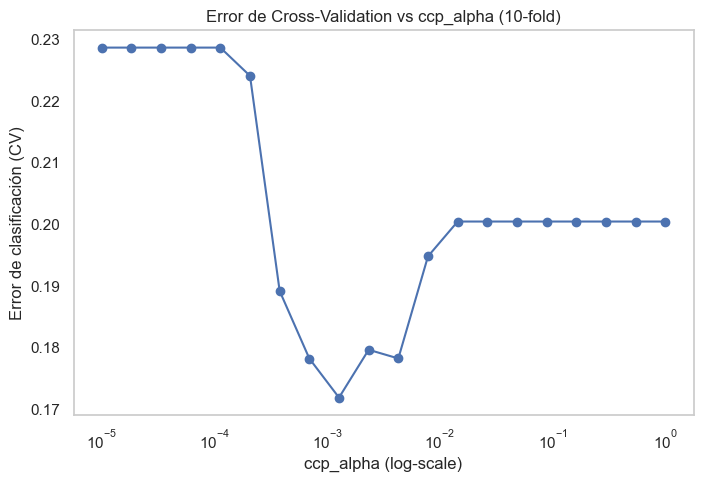

Mejor ccp_alpha según CV: 0.0012742749857031334


In [747]:
# === Gráfico del error en función de ccp_alpha ===
plt.figure(figsize=(8,5))
plt.plot(ccp_grid, cv_errors, marker="o")
plt.xscale("log")
plt.xlabel("ccp_alpha (log-scale)")
plt.ylabel("Error de clasificación (CV)")
plt.title("Error de Cross-Validation vs ccp_alpha (10-fold)")
plt.grid(False)
plt.show()

print("Mejor ccp_alpha según CV:", best_alpha)

In [748]:
#No está en la consigna pero buscamos también el mejor max_depth

depth_errors = []

# definí la grilla de profundidades que quieras evaluar
depth_grid = range(1, 21)   # por ejemplo de 1 a 20

for depth in depth_grid:
    tree = DecisionTreeClassifier(random_state=100, max_depth=depth)
    scores = cross_val_score(tree, X_train, y_train, cv=10, scoring="accuracy")
    
    # Error de clasificación = 1 - accuracy
    depth_errors.append(1 - scores.mean())

depth_errors = np.array(depth_errors)

best_depth = depth_grid[np.argmin(depth_errors)]
print("Mejor max_depth:", best_depth)

Mejor max_depth: 4


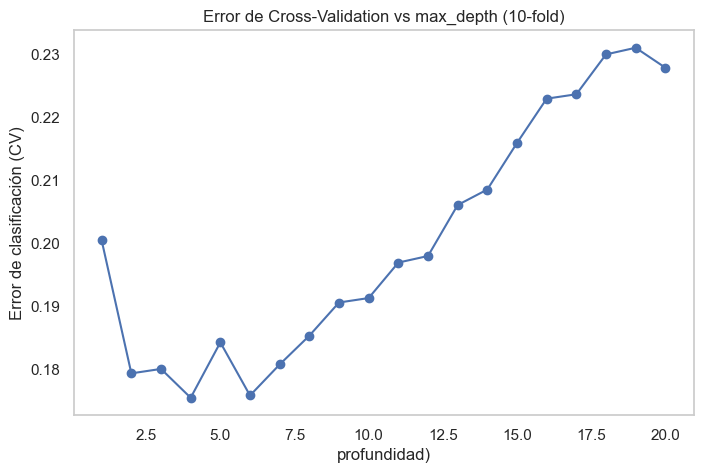

Mejor depth según CV: 4


In [749]:
# === Gráfico del error en función de ccp_alpha ===
plt.figure(figsize=(8,5))
plt.plot(depth_grid, depth_errors, marker="o")
plt.xlabel("profundidad)")
plt.ylabel("Error de clasificación (CV)")
plt.title("Error de Cross-Validation vs max_depth (10-fold)")
plt.grid(False)
plt.show()

print("Mejor depth según CV:", best_depth)

## 5. Visualización del árbol podado + Importancia de predictores

In [751]:
# === Entrenar el CART final con el mejor alpha ===
tree_pruned = DecisionTreeClassifier(random_state=100, ccp_alpha=best_alpha, max_depth=best_depth)
tree_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0012742749857031334, max_depth=4,
                       random_state=100)

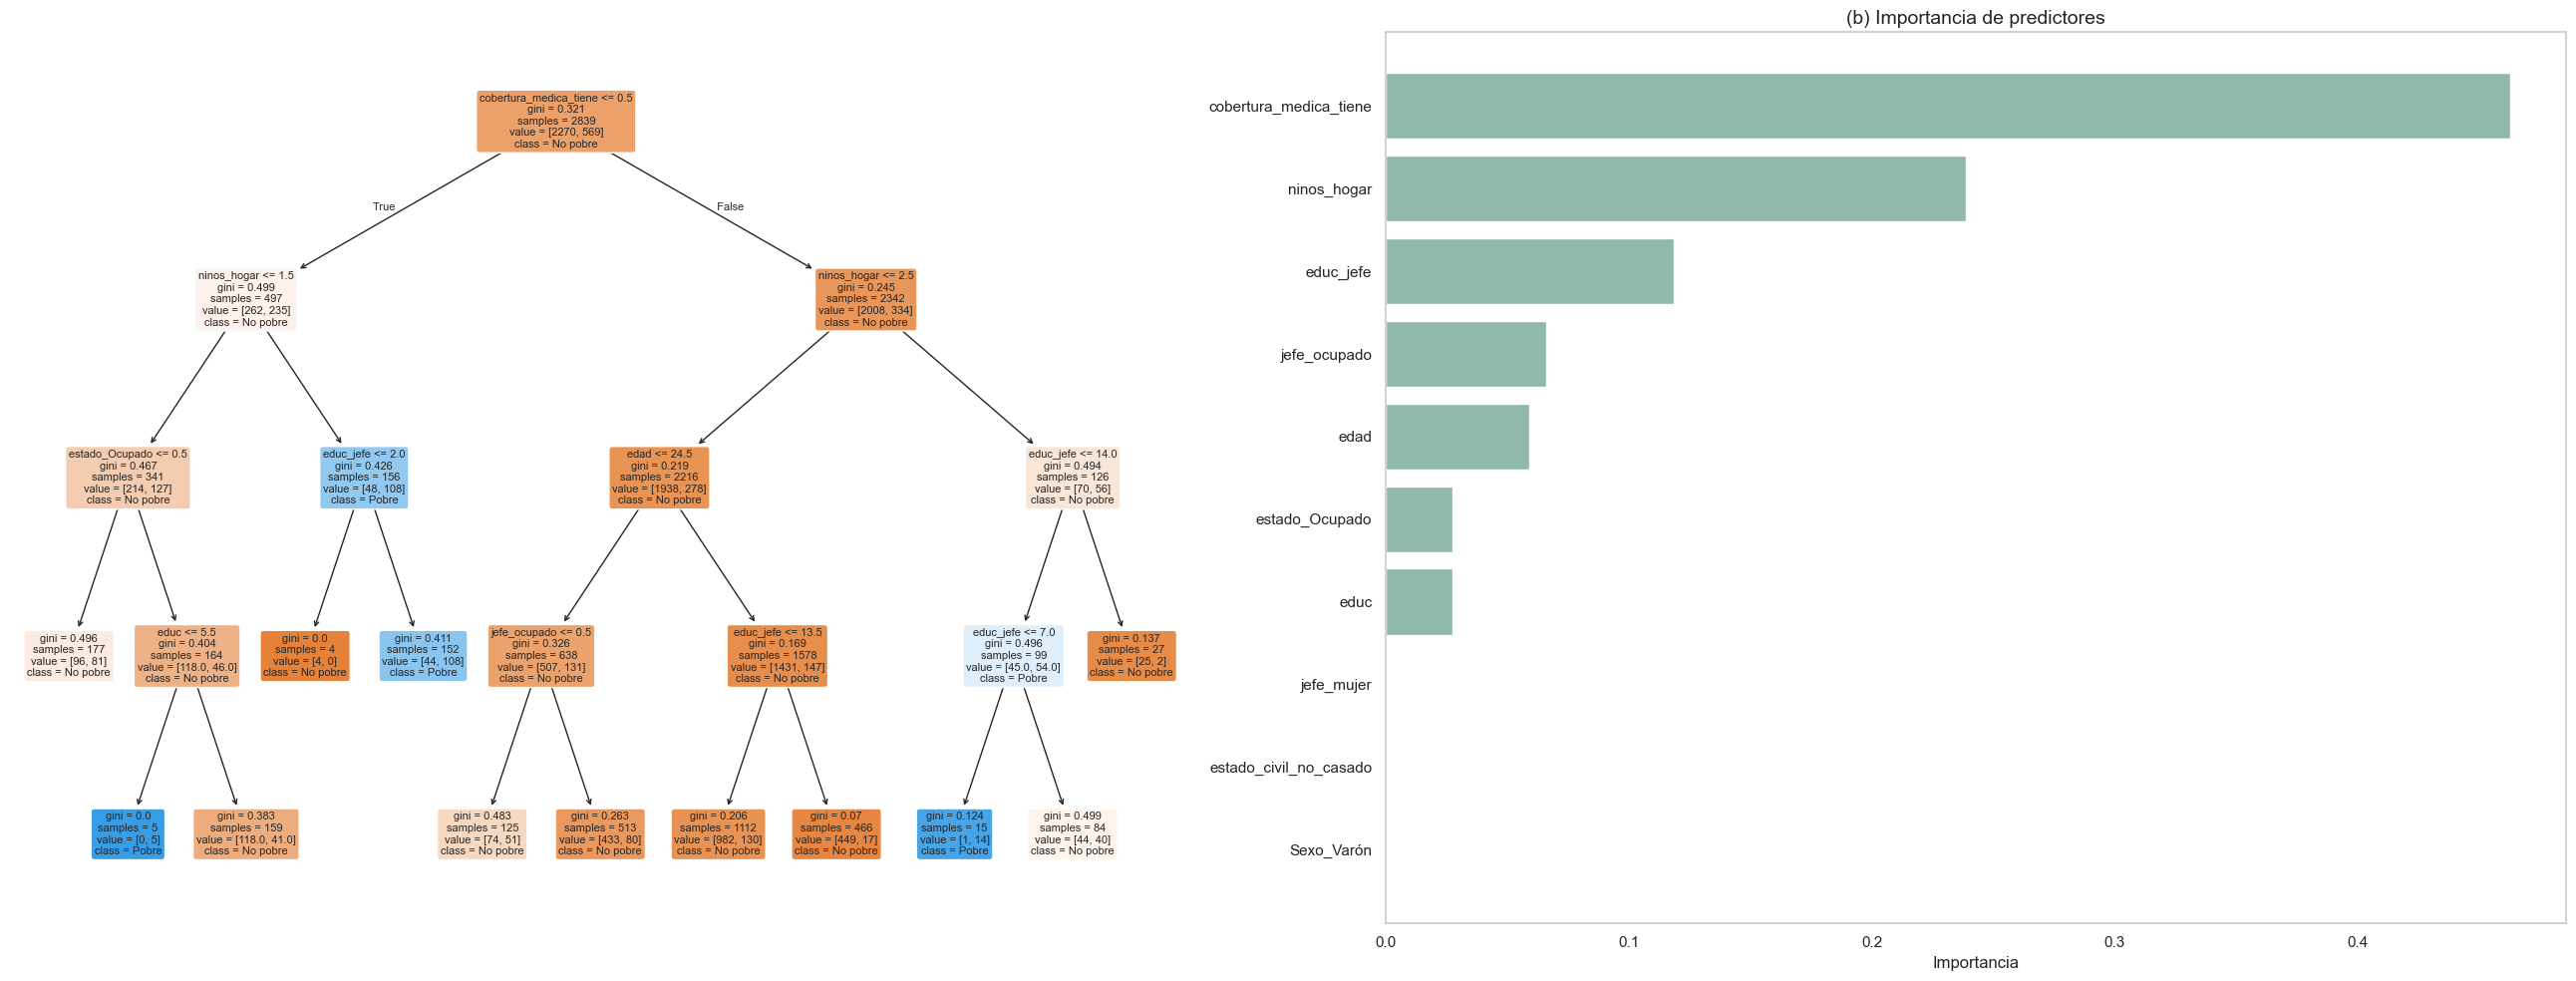

In [752]:

# Importancia de predictores
importancias = tree_pruned.feature_importances_

importancias_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias
}).sort_values("Importancia", ascending=True)

# Crear figura con 2 paneles
fig, axes = plt.subplots(1, 2, figsize=(26, 10))

# Panel A: Árbol de decisión
axes[0].set_title("(a) Árbol de decisión podado (CART)", fontsize=14)
plot_tree(
    tree_pruned,
    feature_names=X_train.columns,
    class_names=["No pobre", "Pobre"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=axes[0]
)

# Panel B: Importancia de predictores ===
axes[1].barh(
    importancias_df["Variable"],
    importancias_df["Importancia"],
    color="#8FB9A8"
)
axes[1].set_title("(b) Importancia de predictores", fontsize=14)
axes[1].set_xlabel("Importancia", fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [753]:
#Tabla
importancias_df.sort_values("Importancia", ascending=False)

,Variable,Importancia
4,cobertura_medica_tiene,0.46
9,ninos_hogar,0.24
7,educ_jefe,0.12
6,jefe_ocupado,0.07
0,edad,0.06
3,estado_Ocupado,0.03
2,educ,0.03
1,Sexo_Varón,0.00
5,estado_civil_no_casado,0.00
8,jefe_mujer,0.00


Efectivamente los predictores que LASSO achicó a cero son los menos importantes

# C. Comparación entre métodos

## 6. Matriz de confusión, curva ROC y métricas

### Entrenamos el LOGIT

In [758]:
# Train–test split estratificado (30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=100
)

# Estimación de la regresión logística (Logit)

# Agregamos constante solo para el Logit
X_train_logit = sm.add_constant(X_train, prepend=True)
X_test_logit = sm.add_constant(X_test, prepend=True)

logit_model = sm.Logit(y_train, X_train_logit)
logit_results = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.405152
         Iterations 6


### Matriz de confusión del Logit

In [760]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score


# Predicciones de probabilidad con el modelo Logit
y_pred_prob_logit = logit_results.predict(X_test_logit)

# Umbral de clasificación
umbral = 0.5
y_pred_logit = (y_pred_prob_logit > umbral).astype(int)

# Matriz de confusión para Logit
cm_logit = confusion_matrix(y_test, y_pred_logit)

print("=== Matriz de confusión – Logit (umbral 0.5) ===")
print(cm_logit)


cm_df = pd.DataFrame(cm_logit,
                     index=["No pobre (Real)", "Pobre (Real)"],
                     columns=["No pobre (Pred)", "Pobre (Pred)"])

print("\nTabla de matriz de confusión:")
print(cm_df)

# exportar a Excel
cm_df.to_excel("matriz_confusion_logit.xlsx", index=True)


=== Matriz de confusión – Logit (umbral 0.5) ===
[[934  37]
 [161  86]]

Tabla de matriz de confusión:
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              934            37
Pobre (Real)                 161            86


### Entrenamos el KNNN

In [762]:
# Selección de K óptimo por Cross-Validation
ks = range(1, 11)
accuracy_cv = []
kf = KFold(n_splits=5, shuffle=True, random_state=100)

for k in ks:
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipe, X_train, y_train, cv=kf, scoring="accuracy")
    accuracy_cv.append(scores.mean())

k_optimo = ks[np.argmax(accuracy_cv)]
print("K óptimo según CV:", k_optimo)


K óptimo según CV: 8


### Matriz de confusión del KNN

In [764]:
# Entrenamos el KNN óptimo en el set de entrenamiento

modelo_knn_opt = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k_optimo))
])
modelo_knn_opt.fit(X_train, y_train)

# Probabilidades predichas de pobreza en el test
y_pred_prob_knn = modelo_knn_opt.predict_proba(X_test)[:, 1]

# Para comparación, también matriz de confusión de KNN con umbral 0.5
y_pred_knn = (y_pred_prob_knn > 0.5).astype(int)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\n=== Matriz de confusión – KNN (K óptimo, umbral 0.5) ===")
print(cm_knn)

cm_df = pd.DataFrame(cm_knn,
                     index=["No pobre (Real)", "Pobre (Real)"],
                     columns=["No pobre (Pred)", "Pobre (Pred)"])

print("\nTabla de matriz de confusión:")
print(cm_df)

# exportar a Excel
cm_df.to_excel("matriz_confusion_knn.xlsx", index=True)


=== Matriz de confusión – KNN (K óptimo, umbral 0.5) ===
[[934  37]
 [172  75]]

Tabla de matriz de confusión:
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              934            37
Pobre (Real)                 172            75


### Estimamos Ridge con lambda obtenido antes

In [766]:
# === Ridge ===
C_best = 1 / mejor_lambda_ridge

ridge = LogisticRegression(
    penalty='l2',
    C=C_best,
    solver='lbfgs',
    max_iter=2000
)
ridge.fit(X_train, y_train)


LogisticRegression(C=99999.99999999999, max_iter=2000)

### Matriz de Confusión Ridge

In [768]:
y_pred_prob_ridge = ridge.predict_proba(X_test)[:,1]
y_pred_ridge = (y_pred_prob_ridge > 0.5).astype(int)

cm_ridge = confusion_matrix(y_test, y_pred_ridge)
print(pd.DataFrame(cm_ridge,
    index=["No pobre (Real)","Pobre (Real)"],
    columns=["No pobre (Pred)", "Pobre (Pred)"]))

                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              934            37
Pobre (Real)                 161            86


### Estimamos LASSO con lambda obtenido antes

In [770]:
# Modelo LASSO (penalidad L1)
C_best = 1/mejor_lambda_lasso

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",  # necesario para L1
    max_iter=1000,
    C=C_best
)
lasso.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=1000, penalty='l1', solver='liblinear')

### Matriz de confusión Lasso

In [772]:
# Probabilidades y clases predichas
y_pred_prob_lasso = lasso.predict_proba(X_test)[:, 1]
y_pred_lasso = (y_pred_prob_lasso > 0.5).astype(int)

# Matriz de confusión
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

cm_lasso_df = pd.DataFrame(
    cm_lasso,
    index=["No pobre (Real)", "Pobre (Real)"],
    columns=["No pobre (Pred)", "Pobre (Pred)"]
)

print("\n=== Matriz de confusión – Logit LASSO (umbral 0.5) ===")
print(cm_lasso_df)


=== Matriz de confusión – Logit LASSO (umbral 0.5) ===
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              964             7
Pobre (Real)                 231            16


### Estimación arbol de decisión y matriz de confusión

In [774]:
y_pred_tree = tree_pruned.predict(X_test)


y_pred_prob_tree = tree_pruned.predict_proba(X_test)[:, 1]
y_pred_tree = (y_pred_prob_tree > 0.5).astype(int)

cm_tree = confusion_matrix(y_test, y_pred_tree)

cm_tree_df = pd.DataFrame(
    cm_tree,
    index=["No pobre (Real)", "Pobre (Real)"],
    columns=["No pobre (Pred)", "Pobre (Pred)"]
)

print("\n=== Matriz de confusión – Árbol de decisión podado ===")
print(cm_tree_df)


=== Matriz de confusión – Árbol de decisión podado ===
                 No pobre (Pred)  Pobre (Pred)
No pobre (Real)              949            22
Pobre (Real)                 193            54


### Todo junto y sumamos las métricas

In [776]:

modelos = {
    "Logit": (y_pred_prob_logit, y_pred_logit),
    f"KNN (K={k_optimo})": (y_pred_prob_knn, y_pred_knn),
    "Logit Ridge": (y_pred_prob_ridge, y_pred_ridge),
    "Logit LASSO": (y_pred_prob_lasso, y_pred_lasso),
    "Árbol podado": (y_pred_prob_tree, y_pred_tree)
}

resultados = []

for nombre, (prob, pred) in modelos.items():
    # Matriz de confusión
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Métricas
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred)          # pobreza = 1
    auc = roc_auc_score(y_test, prob)
    
    resultados.append({
        "Modelo": nombre,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": acc,
        "Recall (pobre=1)": rec,
        "AUC": auc
    })

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados)

# Si querés exportar:
tabla_resultados.to_excel("resultados_todos_modelos.xlsx", index=False)

         Modelo   TN  FP   FN  TP  Accuracy  Recall (pobre=1)  AUC
0         Logit  934  37  161  86      0.84              0.35 0.81
1     KNN (K=8)  934  37  172  75      0.83              0.30 0.75
2   Logit Ridge  934  37  161  86      0.84              0.35 0.81
3   Logit LASSO  964   7  231  16      0.80              0.06 0.76
4  Árbol podado  949  22  193  54      0.82              0.22 0.76


### Curvas ROC

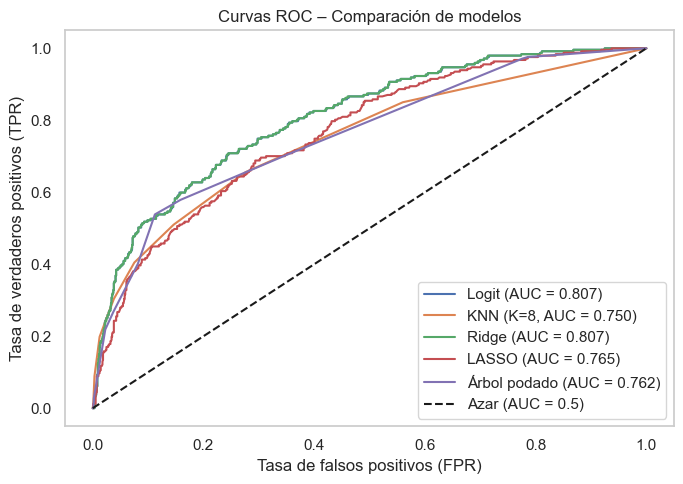

In [817]:
plt.figure(figsize=(7, 5))

# LOGIT
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_pred_prob_logit)
auc_logit = roc_auc_score(y_test, y_pred_prob_logit)
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})")

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
auc_knn = roc_auc_score(y_test, y_pred_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (K={k_optimo}, AUC = {auc_knn:.3f})")

# RIDGE
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_pred_prob_ridge)
auc_ridge = roc_auc_score(y_test, y_pred_prob_ridge)
plt.plot(fpr_ridge, tpr_ridge, label=f"Ridge (AUC = {auc_ridge:.3f})")

# LASSO
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_pred_prob_lasso)
auc_lasso = roc_auc_score(y_test, y_pred_prob_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO (AUC = {auc_lasso:.3f})")

# ÁRBOL PODADO
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_prob_tree)
auc_tree = roc_auc_score(y_test, y_pred_prob_tree)
plt.plot(fpr_tree, tpr_tree, label=f"Árbol podado (AUC = {auc_tree:.3f})")

# Línea base
plt.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.5)")

# Etiquetas
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC – Comparación de modelos")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()